# Music Clustering Project

## Project Description
Music streaming platforms like Spotify generate vast amounts of data related to song characteristics, user preferences, and listening habits. Understanding patterns in this data can help in tasks such as music recommendation, playlist generation, and genre discovery. In this project you are to focus on using clustering techniques to group songs based on their audio features, uncovering hidden structures in the dataset. By analyzing these clusters, one can gain insights into different music styles and potentially enhance recommendation systems.

## Dataset
The dataset to be used in this project is supposed to be obtained from the Spotify Platform, once you obtain the Developer API Key. Alternatively, if you are not able to connect to Spotify, you can use this data.  Ideally, the dataset should contain various audio features for songs, including:
- Acousticness: A measure of acoustic sound in a track
- Danceability: How suitable a track is for dancing
- Energy: Intensity and activity level of a song
- Instrumentalness: The presence of vocals in a track
- Liveness: Detects the presence of a live audience
- Loudness: The overall loudness of a track
- Speechiness: The presence of spoken words in a track
- Tempo: The beats per minute (BPM) of a song
- Valence: The musical positiveness of a track

The dataset may require preprocessing steps such as handling missing values, normalizing features, and removing duplicates before applying clustering models.

## Resources

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as mn
import seaborn as sns

In [8]:
data = pd.read_csv(r'./ML_spotify_data.csv')

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          10000 non-null  str    
 1   artists       10000 non-null  str    
 2   popularity    10000 non-null  int64  
 3   danceability  10000 non-null  float64
 4   valence       10000 non-null  float64
 5   energy        10000 non-null  float64
 6   explicit      10000 non-null  int64  
 7   key           10000 non-null  int64  
 8   liveness      10000 non-null  float64
 9   loudness      10000 non-null  float64
 10  speechiness   10000 non-null  float64
 11  tempo         10000 non-null  float64
dtypes: float64(7), int64(3), str(2)
memory usage: 937.6 KB


In [9]:
data.head()

,name,artists,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,We're For The Dark - Remastered 2010,['Badfinger'],22,0.678,0.559,0.432,0,3,0.0727,-12.696,0.0334,117.674
1,Sixty Years On - Piano Demo,['Elton John'],25,0.456,0.259,0.368,0,6,0.1560,-10.692,0.0280,143.783
2,Got to Find Another Way,['The Guess Who'],21,0.433,0.833,0.724,0,0,0.1700,-9.803,0.0378,84.341
3,Feelin' Alright - Live At The Fillmore East/1970,['Joe Cocker'],22,0.436,0.870,0.914,0,5,0.8550,-6.955,0.0610,174.005
4,Caravan - Take 7,['Van Morrison'],23,0.669,0.564,0.412,0,7,0.4010,-13.095,0.0679,78.716


In [11]:
num_df = data.select_dtypes(include=np.number)
cat_df = data.select_dtypes(exclude=np.number)

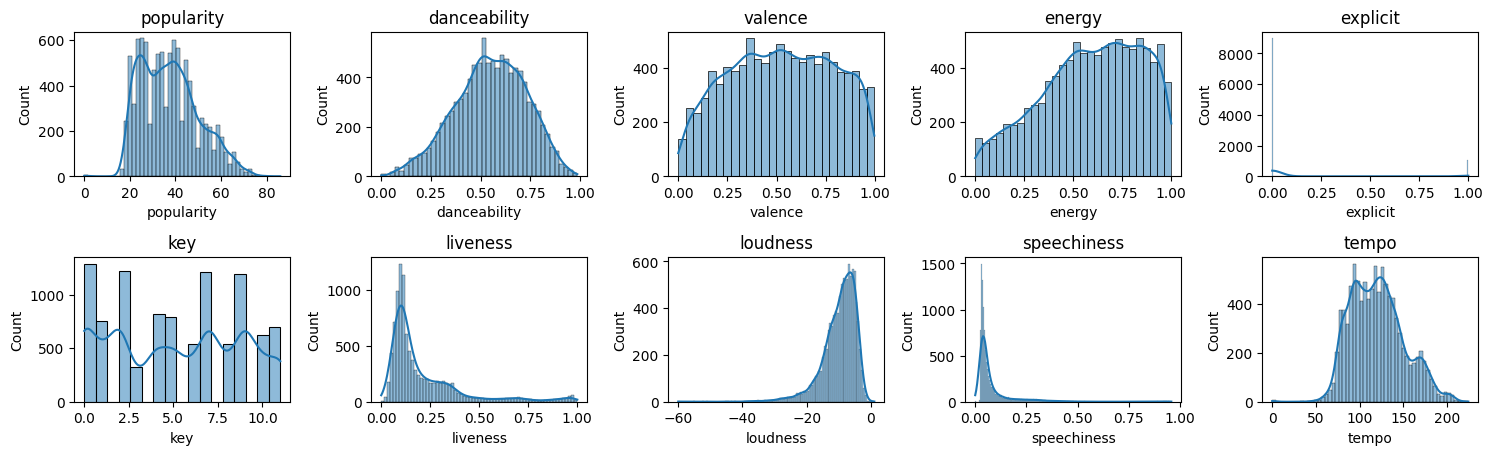

In [15]:
fig = plt.figure(figsize=(15,20))
for i in range(len(num_df.columns)):
    ax=fig.add_subplot(9, 5, i+1)
    sns.histplot(x=num_df.iloc[:, i],ax=ax,kde=True)
    ax.set_title(num_df.columns[i])
    
plt.tight_layout()
plt.show()

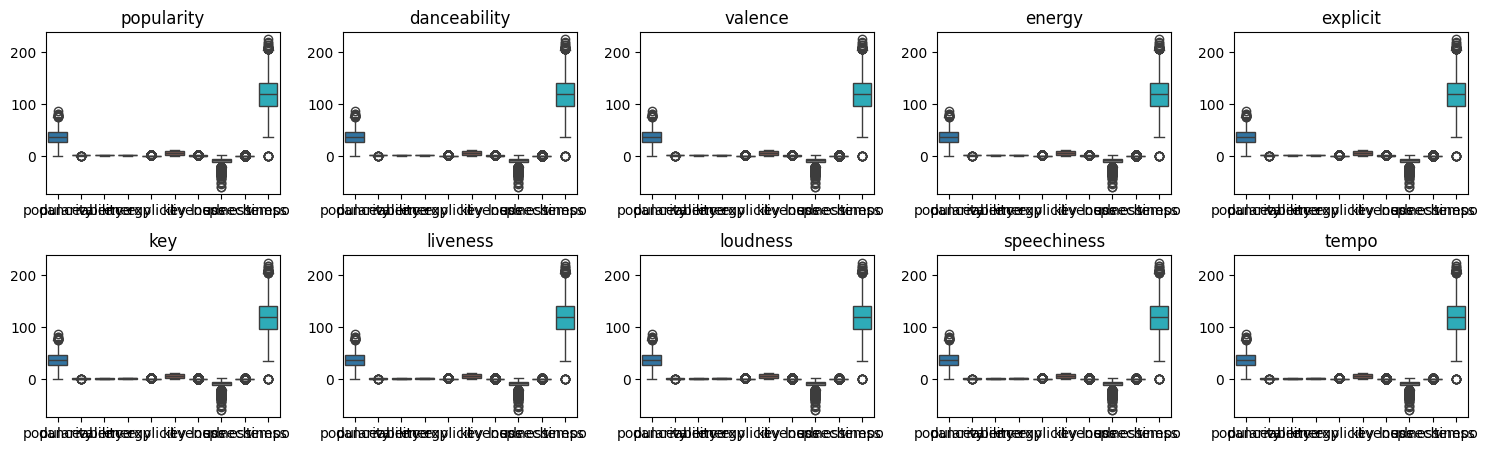

In [17]:
fig = plt.figure(figsize=(15,20))
for i in range(len(num_df.columns)):
    ax=fig.add_subplot(9, 5, i+1)
    sns.boxplot(num_df)
    ax.set_title(num_df.columns[i])
    
plt.tight_layout()
plt.show()

In [28]:
data.nunique()

name            9711
artists         5723
popularity        68
danceability     903
valence         1225
energy          1216
explicit           2
key               12
liveness        1453
loudness        7405
speechiness     1171
tempo           9370
dtype: int64

In [29]:
data['artists'].value_counts()

artists
['U2']                                                          33
['Queen']                                                       26
['Fleetwood Mac']                                               25
['Bob Dylan']                                                   25
['The Rolling Stones']                                          24
                                                                ..
['Ólafur Arnalds']                                               1
['Najma Wallin']                                                 1
['Anuel AA', 'Daddy Yankee', 'KAROL G', 'Ozuna', 'J Balvin']     1
['Ashnikko']                                                     1
['KEVVO', 'J Balvin']                                            1
Name: count, Length: 5723, dtype: int64

<Axes: >

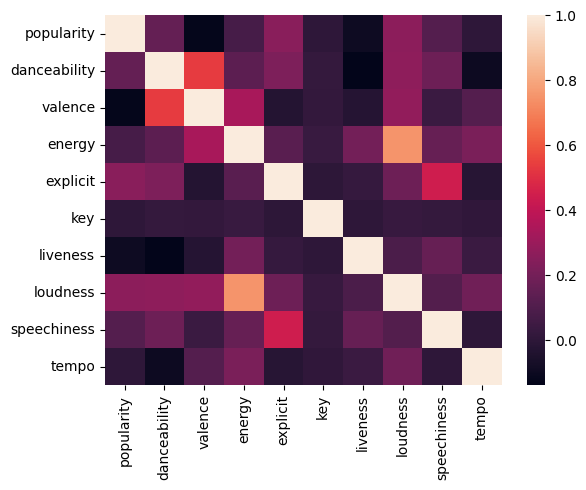

In [36]:
# correlation matrix

cormat = df.corr()
sns.heatmap(cormat)

### Scaling

In [31]:
from sklearn.preprocessing import RobustScaler

df = data.drop(columns=['name','artists'])
scaler = RobustScaler()

df_scaled = scaler.fit_transform(df)
df_scaled.shape

(10000, 10)

## Clustering

In [32]:
from scipy.cluster.hierarchy import linkage, dendrogram

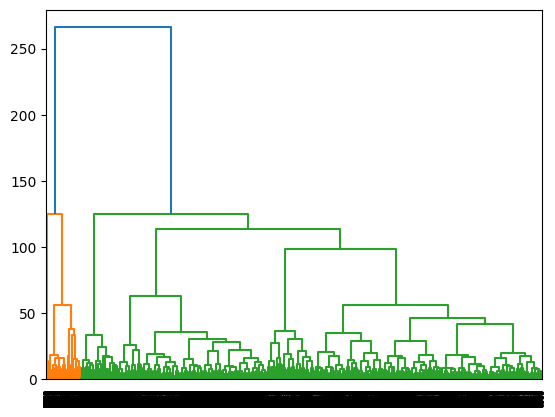

In [33]:
# start  with hierarchical clustering

wards_clustering = linkage(df_scaled, method='ward')
dendrogram(wards_clustering)
plt.show()

In [34]:
# apply k-means clustering

from sklearn.cluster import KMeans

In [35]:
kmeans = KMeans(n_clusters=5, random_state=0,init='k-means++',n_init="auto").fit(df_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_


print(centroids)
print("\nCluster Labels for Data Points:")
print(labels)

[[ 1.35144370e-01  1.22462891e-01  1.78083401e-01  1.78533414e-01
   7.36374509e-02  3.70750043e-02  1.78331373e-01  1.50833175e-01
   2.52037575e-01  1.23224826e-01]
 [ 4.14911383e-01  4.61704869e-01  9.51289925e-02  1.76924250e-01
   5.20982600e-01  5.73183214e-02  5.30646458e-01  2.18721668e-01
   5.59290297e+00  6.44101913e-02]
 [-1.84603299e-01  6.90372837e-02 -1.93142678e-01 -8.92822708e-02
   4.47761194e-01 -2.13219616e-03  2.58642848e+00 -7.96225199e-01
   1.78462894e+01 -3.51470438e-01]
 [-1.33650097e-01 -3.70499022e-01 -6.66343186e-02  2.55380784e-01
   5.09259259e-02  2.82738095e-02  3.38756930e+00 -1.82210760e-02
   5.75703018e-01  1.48417226e-01]
 [-1.11280882e-01 -5.14019669e-01 -4.89620541e-01 -9.09735813e-01
   8.03930326e-03 -1.59509985e-03  7.37166986e-02 -1.21339121e+00
  -9.99061254e-02 -2.06761287e-01]]

Cluster Labels for Data Points:
[4 4 0 ... 0 1 0]


In [37]:
from sklearn.metrics import silhouette_score
silhouette_score(df_scaled, kmeans.labels_, metric='euclidean')

0.22557349248111105

In [38]:
# how to optimise for the value of k
# In machine learning, inertia measures the compactness of clusters in clustering algorithms like K-Means. It is calculated as the sum of the squared distances of each data point to its cluster centroid, with lower values indicating better clustering quality.

inertias = []
sil_scores = []
k_range = range(2,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0, init='k-means++', n_init='auto').fit(df_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(df_scaled, kmeans.labels_))

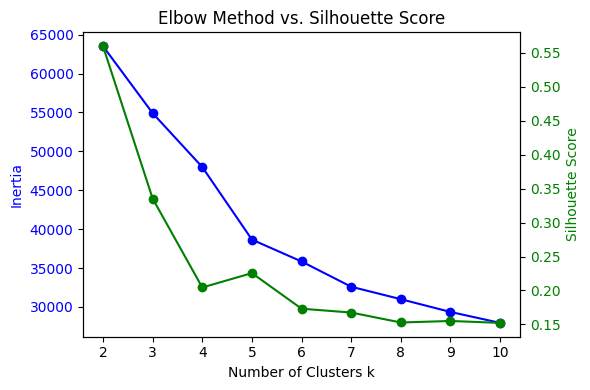

In [39]:
fig, ax1 = plt.subplots(figsize=(6, 4))

#Inertia (Elbow Method)
ax1.plot(k_range, inertias, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters k')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

#Silhouette Score
ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 'go-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='g')
ax2.tick_params(axis='y', labelcolor='g')

plt.title('Elbow Method vs. Silhouette Score')
fig.tight_layout()
plt.show()

In [40]:
kmeans_final = KMeans(n_clusters=10, random_state=42, 
                      init='k-means++', n_init='auto')
kmeans_final.fit(df_scaled)
labels_kmeans = kmeans_final.labels_

In [41]:
import collections

print(collections.Counter(labels_kmeans))

Counter({np.int32(8): 1997, np.int32(6): 1832, np.int32(3): 1819, np.int32(0): 1487, np.int32(7): 807, np.int32(2): 706, np.int32(1): 552, np.int32(5): 538, np.int32(9): 211, np.int32(4): 51})


In [42]:
# apply gaussian mixture models

from sklearn.mixture import GaussianMixture

In [47]:
gmm = GaussianMixture(n_components=5,covariance_type='full', random_state=42)

# Fit the model
gmm.fit(df_scaled)

# Get cluster labels and probabilities
labels = gmm.predict(df_scaled)
probs = gmm.predict_proba(df_scaled)

In [48]:
print(collections.Counter(labels))

Counter({np.int64(3): 3673, np.int64(0): 3500, np.int64(2): 1731, np.int64(1): 1011, np.int64(4): 85})


In [ ]:
# optimising for the number of gaussian components



In [49]:
gmm = GaussianMixture(n_components=3,covariance_type='full', random_state=42)

# Fit the model
gmm.fit(df_scaled)

# Get cluster labels and probabilities
labels_optimised = gmm.predict(df_scaled)
probs = gmm.predict_proba(df_scaled)

print(collections.Counter(labels_optimised))

Counter({np.int64(0): 6001, np.int64(2): 2967, np.int64(1): 1032})


In [50]:
# apply dbscan

from sklearn.cluster import DBSCAN

In [52]:
dbscan = DBSCAN(eps=2, min_samples=5)
labels_dbscan = dbscan.fit_predict(df_scaled)

print(collections.Counter(labels_dbscan))

Counter({np.int64(0): 9893, np.int64(-1): 78, np.int64(1): 29})


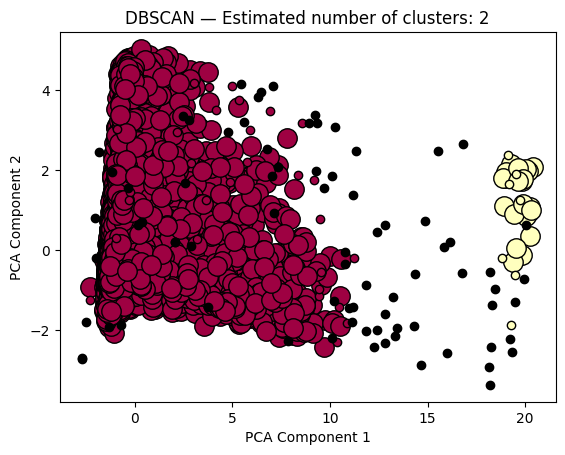

In [53]:
from sklearn.decomposition import PCA

# Reduce to 2D for plotting
pca = PCA(n_components=2)
X_2d = pca.fit_transform(df_scaled)

unique_labels = set(labels_dbscan)
core_samples_mask = np.zeros_like(labels_dbscan, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

n_clusters_ = len([k for k in unique_labels if k != -1])

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # black for noise

    class_member_mask = labels_dbscan == k

    xy = X_2d[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o",
             markerfacecolor=tuple(col), markeredgecolor="k", markersize=14)

    xy = X_2d[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o",
             markerfacecolor=tuple(col), markeredgecolor="k", markersize=6)

plt.title(f"DBSCAN — Estimated number of clusters: {n_clusters_}")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [54]:
# apply hdbscan

In [ ]:
# use the cluster labels to perform eda on each of the clusters